# UrbanFlow AI: Büyük Veri Destekli Taksi Talebi Tahmini ve ROI Optimizasyonu

Bu notebook, çalıştırılmış proje dosyasındaki **gerçek hücre çıktıları** ile açıklamalı final notebook şablonundaki **akademik/proje açıklamalarını** birleştirilmiş şekilde içerir.

## Projenin temel amacı

UrbanFlow AI, New York sarı taksi yolculuk verilerini, taksi bölge sözlüğü ve saatlik hava durumu verisiyle birleştirerek bölge-saat düzeyinde yüksek taksi talebi tahmini yapar. Model sonucu yalnızca teknik başarı metrikleriyle değil, aynı zamanda araç yönlendirme kararı, maliyet/fayda analizi, threshold optimizasyonu ve ROI hesaplaması ile değerlendirilir.

## İş problemi

Taksi işletmeleri hangi bölgede, hangi saatte yüksek talep oluşacağını önceden tahmin edebilirse ek araç yönlendirme kararlarını daha verimli verebilir. Bu proje, makine öğrenmesi çıktısını doğrudan operasyonel karar destek mekanizmasına dönüştürmeyi hedefler.

## Kullanılan veri kaynakları

1. **NYC Yellow Taxi Trip Data:** Ocak 2024 ve Şubat 2024 sarı taksi yolculuk kayıtları  
2. **Taxi Zone Lookup:** Lokasyon ID değerlerini borough ve zone bilgileriyle eşleştiren referans veri  
3. **NYC Historical Weather Data:** Saatlik sıcaklık, yağış, rüzgâr ve hava durumu bilgileri  

## Büyük veri mimarisi

JupyterHub → Spark Connect → HDFS Bronze Layer → HDFS Silver Layer → HDFS Gold Layer → Hive External Table → ML / XAI / ROI → Kafka Alert Simulation

## 1. Proje Kurulumu ve Klasör Yapısı

Bu bölümde teslim dosyasının düzenli çalışması için proje klasörleri, HDFS pathleri, Hive tablo adı ve Kafka topic adı tanımlanır. Notebook yeniden çalıştırıldığında `data`, `figures` ve `model_outputs` klasörleri otomatik oluşturulur.

In [8]:
# ============================================================
# 1. PROJECT SETUP
# ============================================================

import os
import uuid
import json
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

RUN_ID = str(uuid.uuid4())[:8]

USERNAME_RAW = os.environ.get("JUPYTERHUB_USER", "adminboot")
USERNAME = USERNAME_RAW.replace("-", "_").lower()

PROJECT_NAME = "urbanflow_ai"
PROJECT_VERSION = "v1_weather"

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
FIGURES_DIR = PROJECT_DIR / "figures"
OUTPUTS_DIR = PROJECT_DIR / "model_outputs"

for directory in [DATA_DIR, RAW_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Büyük veri servis adresleri
SPARK_CONNECT = "sc://spark-connect.spark.svc.cluster.local:15002"
HDFS_NAMENODE = "hdfs://namenode.hadoop.svc.cluster.local:8020"
HIVE_METASTORE = "thrift://hive-metastore.hive.svc.cluster.local:9083"
KAFKA_BOOTSTRAP = "my-kafka.kafka.svc.cluster.local:9092"

# HDFS katmanları
HDFS_BASE = f"{HDFS_NAMENODE}/user/{USERNAME}/urbanflow_ai/{PROJECT_VERSION}"

BRONZE_TRIPS_PATH = f"{HDFS_BASE}/bronze/yellow_taxi"
BRONZE_ZONES_PATH = f"{HDFS_BASE}/bronze/taxi_zones"
BRONZE_WEATHER_PATH = f"{HDFS_BASE}/bronze/weather"

SILVER_ZONE_HOUR_PATH = f"{HDFS_BASE}/silver/zone_hour_demand"
GOLD_ML_PATH = f"{HDFS_BASE}/gold/ml_dataset"

# Hive
DB_NAME = f"student_{USERNAME}"
GOLD_TABLE = "urbanflow_gold_weather_v1"

# Kafka
KAFKA_TOPIC = f"student.{USERNAME}.urbanflow.weather.alerts"

print("========== URBANFLOW AI PROJECT SETUP ==========")
print("RUN_ID:", RUN_ID)
print("USERNAME:", USERNAME)
print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)
print("HDFS_BASE:", HDFS_BASE)
print("Hive Table:", f"{DB_NAME}.{GOLD_TABLE}")
print("Kafka Topic:", KAFKA_TOPIC)

========== URBANFLOW AI PROJECT SETUP ==========
RUN_ID: da2b505b
USERNAME: adminboot
PROJECT_DIR: /home/jovyan
RAW_DIR: /home/jovyan/data/raw
FIGURES_DIR: /home/jovyan/figures
OUTPUTS_DIR: /home/jovyan/model_outputs
HDFS_BASE: hdfs://namenode.hadoop.svc.cluster.local:8020/user/adminboot/urbanflow_ai/v1_weather
Hive Table: student_adminboot.urbanflow_gold_weather_v1
Kafka Topic: student.adminboot.urbanflow.weather.alerts


## 2. Ham Veri ve Paket Kontrolü

Bu bölüm, `data/raw/` klasöründe gerekli tüm veri dosyalarının bulunup bulunmadığını kontrol eder. Ayrıca proje için gerekli Python paketlerinin varlığı doğrulanır. SHAP veya LIME paketlerinden en az birinin bulunması, açıklanabilir yapay zeka bölümü için önemlidir.

In [9]:
# ============================================================
# 2. FILE CHECK + PACKAGE CHECK
# ============================================================

import importlib.util

TAXI_FILES = [
    RAW_DIR / "yellow_tripdata_2024-01.parquet",
    RAW_DIR / "yellow_tripdata_2024-02.parquet",
]

ZONE_FILE = RAW_DIR / "taxi_zone_lookup.csv"
WEATHER_FILE = RAW_DIR / "nyc_weather_2024_01_02.csv"

required_files = TAXI_FILES + [ZONE_FILE, WEATHER_FILE]

print("========== RAW DATA FILE CHECK ==========")
print("Dosyaların aranacağı klasör:", RAW_DIR)

missing_files = []

for file_path in required_files:
    if file_path.exists() and file_path.stat().st_size > 0:
        print(f"[OK] Bulundu: {file_path.name} | size={file_path.stat().st_size}")
    else:
        print(f"[MISSING] Eksik: {file_path.name}")
        missing_files.append(file_path.name)

if missing_files:
    print("\nEksik dosyalar:")
    for f in missing_files:
        print("-", f)
    raise FileNotFoundError("Eksik veri dosyaları var. Dosyaları data/raw klasörüne yükle.")

print("\n[OK] Tüm ham veri dosyaları hazır.")


print("\n========== PACKAGE CHECK ==========")

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "kafka": "kafka-python",
    "shap": "shap",
    "lime": "lime"
}

missing_packages = []

for import_name, package_name in required_packages.items():
    available = importlib.util.find_spec(import_name) is not None
    print(f"{package_name:20s} -> {'OK' if available else 'MISSING'}")

    if not available:
        missing_packages.append(package_name)

has_shap = importlib.util.find_spec("shap") is not None
has_lime = importlib.util.find_spec("lime") is not None

print("\nEksik paketler:", missing_packages if missing_packages else "Yok")

if has_shap or has_lime:
    print("[OK] XAI için SHAP veya LIME mevcut.")
else:
    print("[UYARI] SHAP/LIME eksik. Final XAI bölümü için en az biri kurulmalı.")

========== RAW DATA FILE CHECK ==========
Dosyaların aranacağı klasör: /home/jovyan/data/raw
[OK] Bulundu: yellow_tripdata_2024-01.parquet | size=49961641
[OK] Bulundu: yellow_tripdata_2024-02.parquet | size=50349284
[OK] Bulundu: taxi_zone_lookup.csv | size=12331
[OK] Bulundu: nyc_weather_2024_01_02.csv | size=62547

[OK] Tüm ham veri dosyaları hazır.

========== PACKAGE CHECK ==========
pandas               -> OK
numpy                -> OK
pyarrow              -> OK
scikit-learn         -> OK
matplotlib           -> OK
kafka-python         -> OK
shap                 -> OK
lime                 -> OK

Eksik paketler: Yok
[OK] XAI için SHAP veya LIME mevcut.


## 3. Veri Kaynakları Dosyasının Oluşturulması

Bu hücre, teslim paketinde yer alan `veri_kaynaklari.txt` dosyasını üretir. Böylece kullanılan veri kaynakları, dosya adları ve erişim bağlantıları ayrı bir metin dosyasında belgelenir.

In [10]:
# ============================================================
# 3. CREATE DATA SOURCES FILE
# ============================================================

veri_kaynaklari_text = '''
UrbanFlow AI - Veri Kaynakları

1. NYC Yellow Taxi Trip Data
Kaynak: New York City Taxi & Limousine Commission (TLC) Trip Record Data
Kullanılan dosyalar:
- yellow_tripdata_2024-01.parquet
- yellow_tripdata_2024-02.parquet

Erişim bağlantısı:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Açıklama:
Bu veri seti, New York sarı taksi yolculuklarına ait zaman, mesafe, ücret, ödeme tipi,
pickup ve dropoff lokasyon bilgilerini içermektedir. Projede bölge-saat bazında taksi talebi
tahmini için ana veri kaynağı olarak kullanılmıştır.

2. Taxi Zone Lookup
Kaynak: New York City Taxi & Limousine Commission (TLC) Taxi Zone Lookup
Kullanılan dosya:
- taxi_zone_lookup.csv

Erişim bağlantısı:
https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv

Açıklama:
Bu veri seti, taksi yolculuk verisindeki lokasyon ID değerlerini borough, zone adı ve servis
bölgesi bilgileriyle eşleştirmek için kullanılmıştır.

3. NYC Historical Weather Data
Kaynak: Open-Meteo Historical Weather API
Kullanılan dosya:
- nyc_weather_2024_01_02.csv

Örnek erişim bağlantısı:
https://archive-api.open-meteo.com/v1/archive?latitude=40.7128&longitude=-74.0060&start_date=2024-01-01&end_date=2024-02-29&hourly=temperature_2m,precipitation,rain,snowfall,wind_speed_10m,weather_code&timezone=America%2FNew_York&format=csv

Açıklama:
Bu veri seti, New York için saatlik sıcaklık, yağış, kar, rüzgâr ve hava durumu kodu bilgilerini
içermektedir. Modelin hava koşullarının taksi talebi üzerindeki etkisini öğrenmesi amacıyla
bölge-saat veri setine eklenmiştir.

4. Takvim ve Zaman Tabanlı Türetilmiş Özellikler
Kaynak: Proje kapsamında pickup_datetime değişkeninden türetilmiştir.

Türetilen değişkenler:
- hour_of_day
- day_of_week
- month
- is_weekend
- is_rush_hour
- is_night
- is_holiday

Açıklama:
Bu değişkenler, iş mantığına dayalı feature engineering kapsamında oluşturulmuştur.
'''

veri_path = PROJECT_DIR / "veri_kaynaklari.txt"

with open(veri_path, "w", encoding="utf-8") as f:
    f.write(veri_kaynaklari_text.strip())

print("[OK] Veri kaynakları dosyası oluşturuldu:")
print(veri_path)

[OK] Veri kaynakları dosyası oluşturuldu:
/home/jovyan/veri_kaynaklari.txt


## 4. Spark Connect Oturumu

JupyterHub içinden Spark Connect servisine bağlanılır. Bu proje kapsamında HDFS’e yazma, Hive tablosu oluşturma ve büyük veri dönüşümleri Spark üzerinden yürütülür.

In [11]:
# ============================================================
# 4. SPARK SESSION
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .remote(SPARK_CONNECT) \
    .appName(f"urbanflow-ai-final-weather-{USERNAME}-{RUN_ID}") \
    .config("spark.hadoop.fs.defaultFS", HDFS_NAMENODE) \
    .config("spark.hadoop.hive.metastore.uris", HIVE_METASTORE) \
    .config("spark.sql.shuffle.partitions", "48") \
    .getOrCreate()

print("[OK] SparkSession oluştu")
print("Spark version:", spark.version)

test_count = spark.range(1000).count()
print("[OK] Spark test count:", test_count)

[OK] SparkSession oluştu
Spark version: 3.5.8
[OK] Spark test count: 1000


## 5. Bronze Layer: Ham Verinin HDFS'e Yazılması

Bronze katmanı ham verinin büyük veri depolama alanına alındığı ilk katmandır. Bu aşamada üç farklı veri kaynağı HDFS üzerinde saklanır:

- Yellow Taxi Trip Data
- Taxi Zone Lookup
- Historical Weather Data

Bu yaklaşım, ham verinin korunmasını ve sonraki temizleme/dönüştürme aşamalarının izlenebilir olmasını sağlar.

In [12]:
# ============================================================
# 5. BRONZE LAYER
# ============================================================

import pandas as pd
import numpy as np
import pyarrow.parquet as pq

TAXI_COLUMNS = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount",
    "payment_type"
]

def append_parquet_file_to_hdfs(local_file: Path, hdfs_path: str, first_file: bool, batch_size: int = 100_000):
    print(f"\n[INGEST] {local_file.name}")

    pf = pq.ParquetFile(local_file)

    batch_no = 0
    total_rows = 0

    for batch in pf.iter_batches(batch_size=batch_size, columns=TAXI_COLUMNS):
        pdf_batch = batch.to_pandas()

        pdf_batch = pdf_batch.rename(columns={
            "tpep_pickup_datetime": "pickup_datetime",
            "tpep_dropoff_datetime": "dropoff_datetime",
            "PULocationID": "pickup_zone_id",
            "DOLocationID": "dropoff_zone_id"
        })

        sdf_batch = spark.createDataFrame(pdf_batch)

        write_mode = "overwrite" if first_file and batch_no == 0 else "append"

        sdf_batch.write.mode(write_mode).parquet(hdfs_path)

        batch_no += 1
        total_rows += len(pdf_batch)

        print(f"batch={batch_no}, rows={len(pdf_batch)}, total={total_rows}, mode={write_mode}")

    print(f"[OK] {local_file.name} HDFS Bronze'a yazıldı. rows={total_rows}")


print("========== TAXI TRIP DATA -> HDFS BRONZE ==========")

first_file = True

for taxi_file in TAXI_FILES:
    append_parquet_file_to_hdfs(
        local_file=taxi_file,
        hdfs_path=BRONZE_TRIPS_PATH,
        first_file=first_file,
        batch_size=100_000
    )
    first_file = False

bronze_trips = spark.read.parquet(BRONZE_TRIPS_PATH)

print("\n[OK] Bronze Taxi kayıt sayısı:", bronze_trips.count())
bronze_trips.printSchema()

bronze_trips.select(
    "pickup_datetime",
    "dropoff_datetime",
    "pickup_zone_id",
    "dropoff_zone_id",
    "trip_distance",
    "fare_amount",
    "total_amount"
).show(10, truncate=False)


print("\n========== TAXI ZONE LOOKUP -> HDFS BRONZE ==========")

zones_pdf = pd.read_csv(ZONE_FILE)

zones_pdf.columns = [
    c.strip()
     .replace(" ", "_")
     .replace("/", "_")
    for c in zones_pdf.columns
]

zones_sdf = spark.createDataFrame(zones_pdf)

zones_sdf.write.mode("overwrite").parquet(BRONZE_ZONES_PATH)

bronze_zones = spark.read.parquet(BRONZE_ZONES_PATH)

print("\n[OK] Bronze Taxi Zone kayıt sayısı:", bronze_zones.count())
bronze_zones.printSchema()
bronze_zones.show(10, truncate=False)


print("\n========== WEATHER DATA -> HDFS BRONZE ==========")

def read_open_meteo_csv(weather_file: Path) -> pd.DataFrame:
    '''
    Open-Meteo CSV dosyalarında bazen ilk satırlarda metadata bulunur.
    Bu fonksiyon, gerçek header satırını otomatik bulur.
    '''
    with open(weather_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.lower().startswith("time,"):
            header_idx = i
            break

    if header_idx is None:
        # Bazı dosyalarda doğrudan header olabilir.
        return pd.read_csv(weather_file)

    return pd.read_csv(weather_file, skiprows=header_idx)

weather_pdf = read_open_meteo_csv(WEATHER_FILE)

print("Weather raw columns:")
print(weather_pdf.columns.tolist())

rename_map = {}

for col in weather_pdf.columns:
    c = col.lower().strip()

    if c.startswith("time"):
        rename_map[col] = "weather_time"
    elif c.startswith("temperature_2m"):
        rename_map[col] = "temperature_2m"
    elif c.startswith("precipitation"):
        rename_map[col] = "precipitation_mm"
    elif c.startswith("rain"):
        rename_map[col] = "rain_mm"
    elif c.startswith("snowfall"):
        rename_map[col] = "snowfall_cm"
    elif c.startswith("wind_speed_10m") or c.startswith("windspeed_10m"):
        rename_map[col] = "wind_speed_10m"
    elif c.startswith("weather_code") or c.startswith("weathercode"):
        rename_map[col] = "weather_code"

weather_pdf = weather_pdf.rename(columns=rename_map)

needed_weather_cols = [
    "weather_time",
    "temperature_2m",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_10m",
    "weather_code"
]

missing_weather_cols = [
    c for c in needed_weather_cols
    if c not in weather_pdf.columns
]

if missing_weather_cols:
    raise ValueError(
        f"Weather kolonları eksik: {missing_weather_cols}. "
        f"Mevcut kolonlar: {weather_pdf.columns.tolist()}"
    )

weather_pdf = weather_pdf[needed_weather_cols]

weather_sdf = spark.createDataFrame(weather_pdf)

weather_sdf.write.mode("overwrite").parquet(BRONZE_WEATHER_PATH)

bronze_weather = spark.read.parquet(BRONZE_WEATHER_PATH)

print("\n[OK] Bronze Weather kayıt sayısı:", bronze_weather.count())
bronze_weather.printSchema()
bronze_weather.show(10, truncate=False)

print("\n========== BRONZE LAYER TAMAMLANDI ==========")
print("Bronze Trips Path:", BRONZE_TRIPS_PATH)
print("Bronze Zones Path:", BRONZE_ZONES_PATH)
print("Bronze Weather Path:", BRONZE_WEATHER_PATH)

========== TAXI TRIP DATA -> HDFS BRONZE ==========

[INGEST] yellow_tripdata_2024-01.parquet
batch=1, rows=100000, total=100000, mode=overwrite
batch=2, rows=100000, total=200000, mode=append
batch=3, rows=100000, total=300000, mode=append
batch=4, rows=100000, total=400000, mode=append
batch=5, rows=100000, total=500000, mode=append
batch=6, rows=100000, total=600000, mode=append
batch=7, rows=100000, total=700000, mode=append
batch=8, rows=100000, total=800000, mode=append
batch=9, rows=100000, total=900000, mode=append
batch=10, rows=100000, total=1000000, mode=append
batch=11, rows=100000, total=1100000, mode=append
batch=12, rows=100000, total=1200000, mode=append
batch=13, rows=100000, total=1300000, mode=append
batch=14, rows=100000, total=1400000, mode=append
batch=15, rows=100000, total=1500000, mode=append
batch=16, rows=100000, total=1600000, mode=append
batch=17, rows=100000, total=1700000, mode=append
batch=18, rows=100000, total=1800000, mode=append
batch=19, rows=100000

## 6. Silver Layer: Temizleme, Veri Birleştirme ve Feature Engineering

Silver katmanında ham taksi yolculuk verisi temizlenir, saatlik bölge bazında gruplanır, zone lookup ile zenginleştirilir ve hava durumu verisi saatlik bazda join edilir.

Bu bölümde üretilen başlıca işletme odaklı değişkenler:

- `trip_count_last_1h`
- `trip_count_same_hour_yesterday`
- `rolling_demand_3h`
- `rolling_demand_24h`
- `avg_fare_per_mile_last_24h`
- `zone_revenue_density_last_24h`
- `pickup_dropoff_imbalance_last_3h`
- `weather_severity_score`
- `is_bad_weather`
- `is_rush_hour`
- `is_weekend`
- `is_night`

In [13]:
# ============================================================
# 6. SILVER LAYER
# ============================================================

trips = spark.read.parquet(BRONZE_TRIPS_PATH)
zones = spark.read.parquet(BRONZE_ZONES_PATH)
weather = spark.read.parquet(BRONZE_WEATHER_PATH)

print("Raw trips:", trips.count())
print("Raw zones:", zones.count())
print("Raw weather:", weather.count())


# ------------------------------------------------------------
# 1. Taxi trip cleaning
# ------------------------------------------------------------

trips_clean = trips \
    .withColumn("pickup_datetime", F.to_timestamp("pickup_datetime")) \
    .withColumn("dropoff_datetime", F.to_timestamp("dropoff_datetime")) \
    .withColumn("pickup_zone_id", F.col("pickup_zone_id").cast("int")) \
    .withColumn("dropoff_zone_id", F.col("dropoff_zone_id").cast("int")) \
    .withColumn("passenger_count", F.col("passenger_count").cast("double")) \
    .withColumn("trip_distance", F.col("trip_distance").cast("double")) \
    .withColumn("fare_amount", F.col("fare_amount").cast("double")) \
    .withColumn("tip_amount", F.col("tip_amount").cast("double")) \
    .withColumn("tolls_amount", F.col("tolls_amount").cast("double")) \
    .withColumn("total_amount", F.col("total_amount").cast("double")) \
    .filter(F.col("pickup_datetime").isNotNull()) \
    .filter(F.col("dropoff_datetime").isNotNull()) \
    .filter(F.col("pickup_zone_id").isNotNull()) \
    .filter(F.col("dropoff_zone_id").isNotNull()) \
    .filter(F.col("trip_distance") > 0) \
    .filter(F.col("fare_amount") > 0) \
    .filter(F.col("total_amount") > 0) \
    .filter(F.col("pickup_datetime") >= F.lit("2024-01-01")) \
    .filter(F.col("pickup_datetime") < F.lit("2024-03-01")) \
    .withColumn("pickup_hour", F.date_trunc("hour", F.col("pickup_datetime"))) \
    .withColumn("dropoff_hour", F.date_trunc("hour", F.col("dropoff_datetime")))

print("[OK] Clean taxi trips:", trips_clean.count())

trips_clean.select(
    "pickup_datetime",
    "pickup_zone_id",
    "dropoff_zone_id",
    "trip_distance",
    "fare_amount",
    "total_amount"
).show(10, truncate=False)


# ------------------------------------------------------------
# 2. Zone lookup cleaning
# ------------------------------------------------------------

zones_clean = zones \
    .withColumn("LocationID", F.col("LocationID").cast("int")) \
    .select(
        F.col("LocationID").alias("pickup_zone_id"),
        F.col("Borough").alias("pickup_borough"),
        F.col("Zone").alias("pickup_zone_name"),
        F.col("service_zone").alias("pickup_service_zone")
    )

print("[OK] Zones cleaned")
zones_clean.show(10, truncate=False)


# ------------------------------------------------------------
# 3. Weather cleaning
# ------------------------------------------------------------

weather_clean = weather \
    .withColumn("weather_hour", F.to_timestamp("weather_time")) \
    .withColumn("temperature_2m", F.col("temperature_2m").cast("double")) \
    .withColumn("precipitation_mm", F.col("precipitation_mm").cast("double")) \
    .withColumn("rain_mm", F.col("rain_mm").cast("double")) \
    .withColumn("snowfall_cm", F.col("snowfall_cm").cast("double")) \
    .withColumn("wind_speed_10m", F.col("wind_speed_10m").cast("double")) \
    .withColumn("weather_code", F.col("weather_code").cast("int")) \
    .withColumn(
        "weather_severity_score",
        F.when(F.col("snowfall_cm") > 0, 4)
         .when(F.col("precipitation_mm") >= 5, 3)
         .when(F.col("precipitation_mm") >= 1, 2)
         .when(F.col("precipitation_mm") > 0, 1)
         .otherwise(0)
    ) \
    .withColumn(
        "is_bad_weather",
        F.when(
            (F.col("precipitation_mm") > 0) |
            (F.col("snowfall_cm") > 0) |
            (F.col("wind_speed_10m") >= 30),
            1
        ).otherwise(0)
    ) \
    .select(
        "weather_hour",
        "temperature_2m",
        "precipitation_mm",
        "rain_mm",
        "snowfall_cm",
        "wind_speed_10m",
        "weather_code",
        "weather_severity_score",
        "is_bad_weather"
    )

print("[OK] Weather cleaned")
weather_clean.show(10, truncate=False)


# ------------------------------------------------------------
# 4. Pickup aggregation
# ------------------------------------------------------------

pickup_agg = trips_clean \
    .groupBy("pickup_zone_id", "pickup_hour") \
    .agg(
        F.count("*").alias("trip_count"),
        F.avg("trip_distance").alias("avg_trip_distance"),
        F.avg("fare_amount").alias("avg_fare_amount"),
        F.avg("total_amount").alias("avg_total_amount"),
        F.sum("total_amount").alias("total_revenue"),
        F.avg("tip_amount").alias("avg_tip_amount"),
        F.countDistinct("dropoff_zone_id").alias("unique_dropoff_zones")
    ) \
    .withColumn(
        "avg_fare_per_mile_current",
        F.col("avg_fare_amount") / F.when(F.col("avg_trip_distance") == 0, None).otherwise(F.col("avg_trip_distance"))
    )

print("[OK] Pickup aggregation:", pickup_agg.count())
pickup_agg.show(10, truncate=False)


# ------------------------------------------------------------
# 5. Dropoff aggregation
# ------------------------------------------------------------

dropoff_agg = trips_clean \
    .groupBy(
        F.col("dropoff_zone_id").alias("pickup_zone_id"),
        F.col("dropoff_hour").alias("pickup_hour")
    ) \
    .agg(
        F.count("*").alias("dropoff_count")
    )

print("[OK] Dropoff aggregation:", dropoff_agg.count())
dropoff_agg.show(10, truncate=False)


# ------------------------------------------------------------
# 6. Continuous zone-hour grid
# ------------------------------------------------------------

time_bounds = trips_clean.select(
    F.min("pickup_hour").alias("min_hour"),
    F.max("pickup_hour").alias("max_hour")
).collect()[0]

min_hour = time_bounds["min_hour"]
max_hour = time_bounds["max_hour"]

print("min_hour:", min_hour)
print("max_hour:", max_hour)

hours_df = spark.range(1).select(
    F.explode(
        F.sequence(
            F.lit(min_hour),
            F.lit(max_hour),
            F.expr("interval 1 hour")
        )
    ).alias("pickup_hour")
)

zone_ids_df = zones_clean.select(
    "pickup_zone_id",
    "pickup_borough",
    "pickup_zone_name",
    "pickup_service_zone"
)

zone_hour_grid = zone_ids_df.crossJoin(hours_df)

print("[OK] Zone-hour grid:", zone_hour_grid.count())


# ------------------------------------------------------------
# 7. Silver dataset with weather join
# ------------------------------------------------------------

silver = zone_hour_grid \
    .join(pickup_agg, ["pickup_zone_id", "pickup_hour"], "left") \
    .join(dropoff_agg, ["pickup_zone_id", "pickup_hour"], "left") \
    .join(weather_clean, zone_hour_grid.pickup_hour == weather_clean.weather_hour, "left") \
    .drop("weather_hour") \
    .fillna({
        "trip_count": 0,
        "dropoff_count": 0,
        "total_revenue": 0.0,
        "unique_dropoff_zones": 0,
        "temperature_2m": 0.0,
        "precipitation_mm": 0.0,
        "rain_mm": 0.0,
        "snowfall_cm": 0.0,
        "wind_speed_10m": 0.0,
        "weather_code": 0,
        "weather_severity_score": 0,
        "is_bad_weather": 0
    }) \
    .withColumn("pickup_dropoff_imbalance_current", F.col("trip_count") - F.col("dropoff_count")) \
    .withColumn("date", F.to_date("pickup_hour")) \
    .withColumn("hour_of_day", F.hour("pickup_hour")) \
    .withColumn("day_of_week", F.dayofweek("pickup_hour")) \
    .withColumn("month", F.month("pickup_hour")) \
    .withColumn(
        "is_weekend",
        F.when(F.col("day_of_week").isin([1, 7]), 1).otherwise(0)
    ) \
    .withColumn(
        "is_rush_hour",
        F.when(F.col("hour_of_day").isin([7, 8, 9, 16, 17, 18, 19]), 1).otherwise(0)
    ) \
    .withColumn(
        "is_night",
        F.when((F.col("hour_of_day") >= 22) | (F.col("hour_of_day") <= 5), 1).otherwise(0)
    )

HOLIDAYS = ["2024-01-01", "2024-01-15", "2024-02-19"]

silver = silver.withColumn(
    "is_holiday",
    F.when(F.col("date").cast("string").isin(HOLIDAYS), 1).otherwise(0)
)

silver = silver.orderBy("pickup_zone_id", "pickup_hour")

zone_window = Window.partitionBy("pickup_zone_id").orderBy("pickup_hour")

prev_3h = zone_window.rowsBetween(-3, -1)
prev_24h = zone_window.rowsBetween(-24, -1)

silver = silver \
    .withColumn("trip_count_last_1h", F.lag("trip_count", 1).over(zone_window)) \
    .withColumn("trip_count_same_hour_yesterday", F.lag("trip_count", 24).over(zone_window)) \
    .withColumn("rolling_demand_3h", F.avg("trip_count").over(prev_3h)) \
    .withColumn("rolling_demand_24h", F.avg("trip_count").over(prev_24h)) \
    .withColumn("avg_fare_per_mile_last_24h", F.avg("avg_fare_per_mile_current").over(prev_24h)) \
    .withColumn("zone_revenue_density_last_24h", F.sum("total_revenue").over(prev_24h)) \
    .withColumn("pickup_dropoff_imbalance_last_3h", F.sum("pickup_dropoff_imbalance_current").over(prev_3h)) \
    .withColumn(
        "has_24h_history",
        F.when(F.col("trip_count_same_hour_yesterday").isNotNull(), 1).otherwise(0)
    ) \
    .fillna({
        "trip_count_last_1h": 0,
        "trip_count_same_hour_yesterday": 0,
        "rolling_demand_3h": 0.0,
        "rolling_demand_24h": 0.0,
        "avg_fare_per_mile_last_24h": 0.0,
        "zone_revenue_density_last_24h": 0.0,
        "pickup_dropoff_imbalance_last_3h": 0.0
    })

silver.write.mode("overwrite").parquet(SILVER_ZONE_HOUR_PATH)

silver_read = spark.read.parquet(SILVER_ZONE_HOUR_PATH)

print("[OK] Silver zone-hour dataset yazıldı")
print("Silver kayıt sayısı:", silver_read.count())

silver_read.select(
    "pickup_zone_id",
    "pickup_zone_name",
    "pickup_hour",
    "trip_count",
    "dropoff_count",
    "hour_of_day",
    "is_rush_hour",
    "temperature_2m",
    "precipitation_mm",
    "weather_severity_score",
    "is_bad_weather",
    "trip_count_last_1h",
    "trip_count_same_hour_yesterday",
    "rolling_demand_3h",
    "rolling_demand_24h"
).show(20, truncate=False)

Raw trips: 5972150
Raw zones: 265
Raw weather: 1440
[OK] Clean taxi trips: 5771169
+-------------------+--------------+---------------+-------------+-----------+------------+
|pickup_datetime    |pickup_zone_id|dropoff_zone_id|trip_distance|fare_amount|total_amount|
+-------------------+--------------+---------------+-------------+-----------+------------+
|2024-01-07 00:03:36|79            |231            |1.93         |13.1       |17.1        |
|2024-01-07 00:14:30|168           |95             |10.82        |32.89      |41.33       |
|2024-01-07 00:04:27|211           |263            |4.18         |23.14      |27.14       |
|2024-01-07 00:03:47|113           |239            |4.29         |20.63      |24.63       |
|2024-01-07 00:25:06|48            |249            |2.1          |10.7       |18.05       |
|2024-01-07 00:06:45|107           |137            |0.72         |6.83       |10.83       |
|2024-01-07 00:02:31|249           |239            |4.24         |19.88      |23.88      

## 7. Gold Layer ve Hedef Değişken

Gold katmanında modelleme için kullanılacak final veri seti oluşturulur. `high_demand` hedef değişkeni, talep olan saatlerdeki 75. yüzdelik değere göre belirlenmiştir. Bu sayede model, bir bölge-saat kombinasyonunda yüksek talep olup olmadığını sınıflandırır.

In [14]:
# ============================================================
# 7. GOLD LAYER + TARGET
# ============================================================

silver_read = spark.read.parquet(SILVER_ZONE_HOUR_PATH)

nonzero_trip_counts = silver_read.filter(F.col("trip_count") > 0)

if nonzero_trip_counts.count() == 0:
    raise ValueError("trip_count > 0 olan kayıt yok. Veri veya tarih aralığı hatalı olabilir.")

demand_threshold = nonzero_trip_counts.approxQuantile(
    "trip_count",
    [0.75],
    0.01
)[0]

demand_threshold = max(float(demand_threshold), 1.0)

print("High demand threshold:", demand_threshold)

gold = silver_read.withColumn(
    "high_demand",
    F.when(F.col("trip_count") >= F.lit(demand_threshold), 1).otherwise(0)
)

gold_ml = gold.select(
    "pickup_zone_id",
    "pickup_borough",
    "pickup_zone_name",
    "pickup_service_zone",
    "pickup_hour",
    "date",
    "trip_count",

    "hour_of_day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "is_holiday",

    "temperature_2m",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_10m",
    "weather_code",
    "weather_severity_score",
    "is_bad_weather",

    "trip_count_last_1h",
    "trip_count_same_hour_yesterday",
    "rolling_demand_3h",
    "rolling_demand_24h",
    "avg_fare_per_mile_last_24h",
    "zone_revenue_density_last_24h",
    "pickup_dropoff_imbalance_last_3h",
    "has_24h_history",

    "high_demand"
)

gold_ml.write.mode("overwrite").parquet(GOLD_ML_PATH)

gold_read = spark.read.parquet(GOLD_ML_PATH)

print("[OK] Gold ML dataset yazıldı")
print("Gold kayıt sayısı:", gold_read.count())

print("\nTarget dağılımı:")
gold_read.groupBy("high_demand").count().orderBy("high_demand").show()

gold_read.show(10, truncate=False)

High demand threshold: 43.0
[OK] Gold ML dataset yazıldı
Gold kayıt sayısı: 381600

Target dağılımı:
+-----------+------+
|high_demand| count|
+-----------+------+
|          0|344029|
|          1| 37571|
+-----------+------+

+--------------+--------------+----------------+-------------------+-------------------+----------+----------+-----------+-----------+-----+----------+------------+--------+----------+--------------+----------------+-------+-----------+--------------+------------+----------------------+--------------+------------------+------------------------------+------------------+------------------+--------------------------+-----------------------------+--------------------------------+---------------+-----------+
|pickup_zone_id|pickup_borough|pickup_zone_name|pickup_service_zone|pickup_hour        |date      |trip_count|hour_of_day|day_of_week|month|is_weekend|is_rush_hour|is_night|is_holiday|temperature_2m|precipitation_mm|rain_mm|snowfall_cm|wind_speed_10m|weather_code

## 8. Hive External Table

Gold veri seti Hive External Table olarak kayıt altına alınır. Böylece final modelleme veri seti SQL ile sorgulanabilir ve büyük veri platformu üzerinde kataloglanmış hale gelir.

In [15]:
# ============================================================
# 8. HIVE EXTERNAL TABLE
# ============================================================

spark.sql(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
spark.sql(f"USE {DB_NAME}")
spark.sql(f"DROP TABLE IF EXISTS {GOLD_TABLE}")

spark.sql(f'''
CREATE TABLE {GOLD_TABLE}
USING PARQUET
LOCATION "{GOLD_ML_PATH}"
''')

print("[OK] Hive External Table oluşturuldu:", f"{DB_NAME}.{GOLD_TABLE}")

spark.sql(f'''
SELECT COUNT(*) AS row_count
FROM {DB_NAME}.{GOLD_TABLE}
''').show()

spark.sql(f'''
SELECT high_demand, COUNT(*) AS count
FROM {DB_NAME}.{GOLD_TABLE}
GROUP BY high_demand
ORDER BY high_demand
''').show()

spark.sql(f'''
SELECT *
FROM {DB_NAME}.{GOLD_TABLE}
LIMIT 5
''').show(truncate=False)

[OK] Hive External Table oluşturuldu: student_adminboot.urbanflow_gold_weather_v1
+---------+
|row_count|
+---------+
|   381600|
+---------+

+-----------+------+
|high_demand| count|
+-----------+------+
|          0|344029|
|          1| 37571|
+-----------+------+

+--------------+--------------+----------------+-------------------+-------------------+----------+----------+-----------+-----------+-----+----------+------------+--------+----------+--------------+----------------+-------+-----------+--------------+------------+----------------------+--------------+------------------+------------------------------+------------------+------------------+--------------------------+-----------------------------+--------------------------------+---------------+-----------+
|pickup_zone_id|pickup_borough|pickup_zone_name|pickup_service_zone|pickup_hour        |date      |trip_count|hour_of_day|day_of_week|month|is_weekend|is_rush_hour|is_night|is_holiday|temperature_2m|precipitation_mm|rain_

## 9. Keşifçi Veri Analizi (EDA)

Bu bölümde Gold veri seti analiz için pandas DataFrame formatına alınır. EDA kısmında talebin saatlere, bölgelere, sınıf dağılımına, hava koşullarına ve yoğun saat etkisine göre nasıl değiştiği görselleştirilir.

In [16]:
# ============================================================
# 9. EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

eda_pdf = spark.sql(f'''
SELECT *
FROM {DB_NAME}.{GOLD_TABLE}
''').toPandas()

print("EDA dataset shape:", eda_pdf.shape)
display(eda_pdf.head())

EDA dataset shape: (381600, 31)


,pickup_zone_id,pickup_borough,pickup_zone_name,pickup_service_zone,pickup_hour,date,trip_count,hour_of_day,day_of_week,month,...,is_bad_weather,trip_count_last_1h,trip_count_same_hour_yesterday,rolling_demand_3h,rolling_demand_24h,avg_fare_per_mile_last_24h,zone_revenue_density_last_24h,pickup_dropoff_imbalance_last_3h,has_24h_history,high_demand
0,4,Manhattan,Alphabet City,Yellow Zone,2024-01-01 00:00:00,2024-01-01,22,0,2,1,...,0,0,0,0.000000,0.000000,0.000000,0.00,0,0,0
1,4,Manhattan,Alphabet City,Yellow Zone,2024-01-01 01:00:00,2024-01-01,26,1,2,1,...,0,22,0,22.000000,22.000000,6.564140,637.53,-6,0,0
2,4,Manhattan,Alphabet City,Yellow Zone,2024-01-01 02:00:00,2024-01-01,31,2,2,1,...,0,26,0,24.000000,24.000000,6.193733,1449.98,-14,0,0
3,4,Manhattan,Alphabet City,Yellow Zone,2024-01-01 03:00:00,2024-01-01,27,3,2,1,...,0,31,0,26.333333,26.333333,6.289337,2465.15,-34,0,0
4,4,Manhattan,Alphabet City,Yellow Zone,2024-01-01 04:00:00,2024-01-01,29,4,2,1,...,0,27,0,28.000000,26.500000,6.253613,3458.49,-45,0,0


### 9.1 Saatlere Göre Ortalama Talep

Bu grafik, gün içindeki saatlere göre ortalama taksi talebini gösterir. Böylece günlük talep döngüsü ve yoğun saat davranışı incelenir.

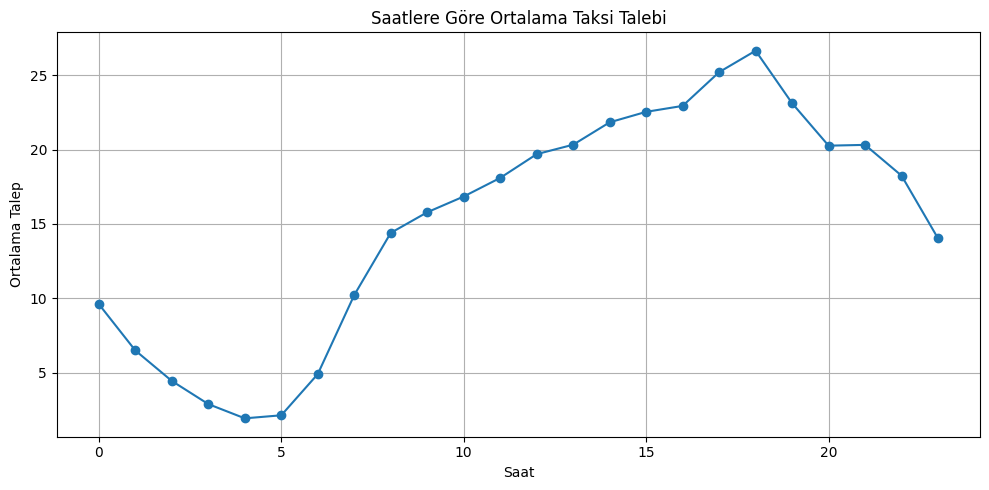

Kaydedildi: /home/jovyan/figures/eda_hourly_demand.png


In [17]:
# Saatlere göre ortalama talep

hourly_demand = (
    eda_pdf
    .groupby("hour_of_day", as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "avg_trip_count"})
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand["hour_of_day"], hourly_demand["avg_trip_count"], marker="o")
plt.title("Saatlere Göre Ortalama Taksi Talebi")
plt.xlabel("Saat")
plt.ylabel("Ortalama Talep")
plt.grid(True)
plt.tight_layout()

fig_path = FIGURES_DIR / "eda_hourly_demand.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

### 9.2 En Yüksek Talebe Sahip Bölgeler

Bu grafik, toplam taksi talebinin en yoğun olduğu bölgeleri göstermektedir. Bölgesel talep yoğunluğu araç konumlandırma kararları için önemlidir.

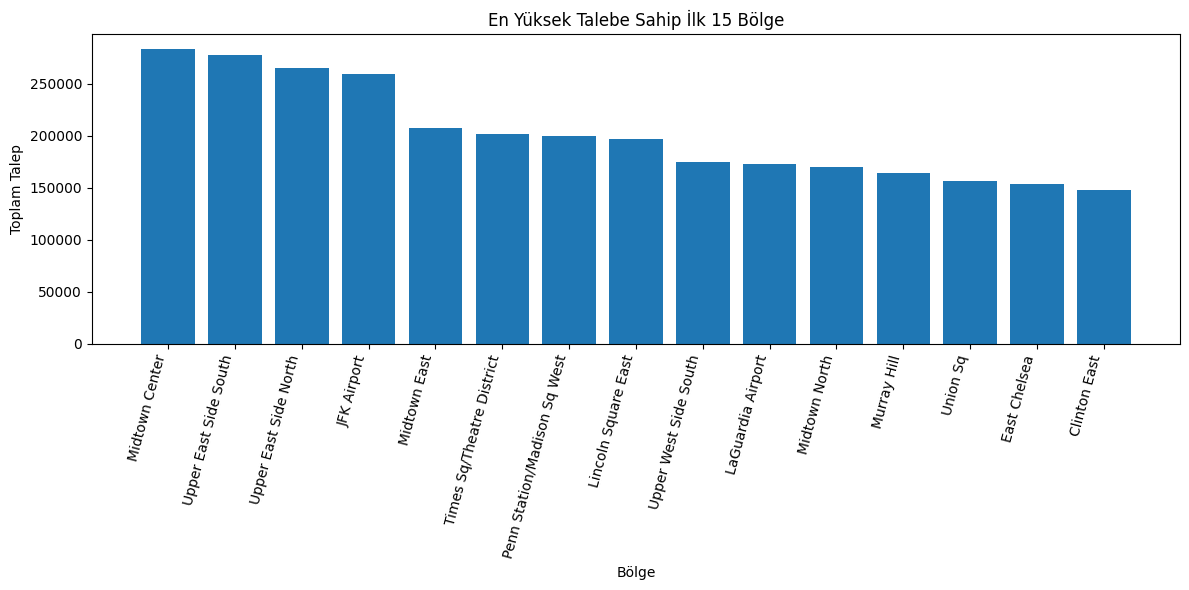

Kaydedildi: /home/jovyan/figures/eda_top_zones.png


In [18]:
# En yüksek talebe sahip bölgeler

zone_demand = (
    eda_pdf
    .groupby("pickup_zone_name", as_index=False)["trip_count"]
    .sum()
    .sort_values("trip_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.bar(zone_demand["pickup_zone_name"], zone_demand["trip_count"])
plt.title("En Yüksek Talebe Sahip İlk 15 Bölge")
plt.xlabel("Bölge")
plt.ylabel("Toplam Talep")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()

fig_path = FIGURES_DIR / "eda_top_zones.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

### 9.3 High Demand Sınıf Dağılımı

Bu grafik, modelin tahmin etmeye çalıştığı `high_demand` hedef değişkeninin sınıf dağılımını gösterir. Yüksek talep sınıfı daha az görüldüğü için modellemede dengesiz sınıf problemi dikkate alınmıştır.

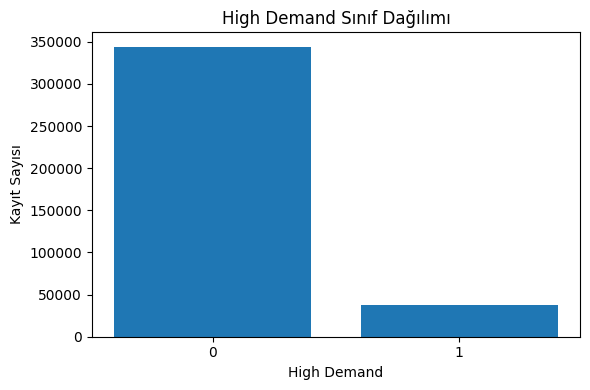

Kaydedildi: /home/jovyan/figures/eda_target_distribution.png


In [19]:
# High demand sınıf dağılımı

class_dist = (
    eda_pdf
    .groupby("high_demand", as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

plt.figure(figsize=(6, 4))
plt.bar(class_dist["high_demand"].astype(str), class_dist["count"])
plt.title("High Demand Sınıf Dağılımı")
plt.xlabel("High Demand")
plt.ylabel("Kayıt Sayısı")
plt.tight_layout()

fig_path = FIGURES_DIR / "eda_target_distribution.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

### 9.4 Hava Durumu Şiddetine Göre Ortalama Talep

Bu grafik, hava durumu şiddetinin ortalama talep ile ilişkisini incelemek için üretilmiştir. Weather verisi modele destekleyici sinyal olarak eklenmiştir.

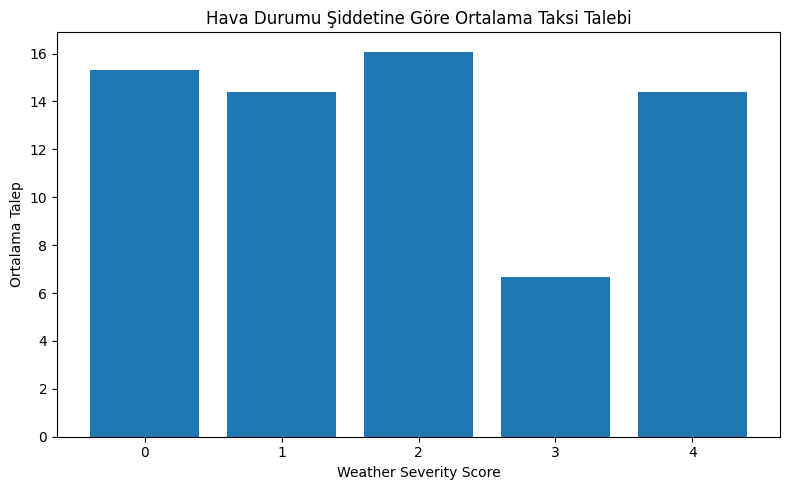

Kaydedildi: /home/jovyan/figures/eda_weather_severity_demand.png


In [20]:
# Hava durumu şiddetine göre ortalama talep

weather_demand = (
    eda_pdf
    .groupby("weather_severity_score", as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "avg_trip_count"})
)

plt.figure(figsize=(8, 5))
plt.bar(weather_demand["weather_severity_score"].astype(str), weather_demand["avg_trip_count"])
plt.title("Hava Durumu Şiddetine Göre Ortalama Taksi Talebi")
plt.xlabel("Weather Severity Score")
plt.ylabel("Ortalama Talep")
plt.tight_layout()

fig_path = FIGURES_DIR / "eda_weather_severity_demand.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

### 9.5 Rush Hour Etkisi

Bu grafik, yoğun saatlerdeki ortalama talep ile yoğun olmayan saatlerdeki talebi karşılaştırır.

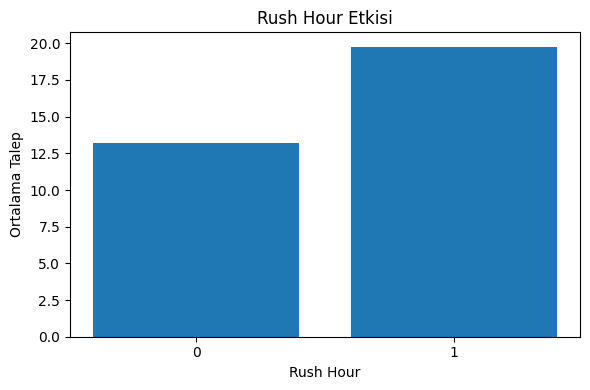

Kaydedildi: /home/jovyan/figures/eda_rush_hour_effect.png


In [21]:
# Rush hour etkisi

rush_effect = (
    eda_pdf
    .groupby("is_rush_hour", as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "avg_trip_count"})
)

plt.figure(figsize=(6, 4))
plt.bar(rush_effect["is_rush_hour"].astype(str), rush_effect["avg_trip_count"])
plt.title("Rush Hour Etkisi")
plt.xlabel("Rush Hour")
plt.ylabel("Ortalama Talep")
plt.tight_layout()

fig_path = FIGURES_DIR / "eda_rush_hour_effect.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

## 10. Modelleme

Bu bölümde yüksek talep tahmini için üç farklı sınıflandırma modeli karşılaştırılır:

1. Logistic Regression  
2. Random Forest  
3. HistGradientBoostingClassifier  

Model değerlendirmesi Accuracy, Precision, Recall, F1-score ve ROC-AUC metrikleriyle yapılmıştır. Sonuçlara göre en iyi model **HistGradientBoosting** olmuştur.

In [5]:
# ============================================================
# 10. MODELING
# ============================================================

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model_df = eda_pdf.copy()

feature_cols = [
    "pickup_zone_id",
    "hour_of_day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "is_holiday",

    "temperature_2m",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_10m",
    "weather_code",
    "weather_severity_score",
    "is_bad_weather",

    "trip_count_last_1h",
    "trip_count_same_hour_yesterday",
    "rolling_demand_3h",
    "rolling_demand_24h",
    "avg_fare_per_mile_last_24h",
    "zone_revenue_density_last_24h",
    "pickup_dropoff_imbalance_last_3h",
    "has_24h_history"
]

target_col = "high_demand"

model_df = model_df.dropna(subset=feature_cols + [target_col])

MODEL_SAMPLE_N = 120_000

if len(model_df) > MODEL_SAMPLE_N:
    model_df = model_df.sample(MODEL_SAMPLE_N, random_state=42)

X = model_df[feature_cols]
y = model_df[target_col].astype(int)

print("Model dataset shape:", model_df.shape)
print("Target dağılımı:")
print(y.value_counts(normalize=True))

if y.nunique() < 2:
    raise ValueError("Target değişkende tek sınıf var. Modelleme için high_demand dağılımı kontrol edilmeli.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        max_iter=120
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    print("\nTraining:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(metrics)
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

print("\nModel karşılaştırma tablosu:")
display(results_df)

results_path = OUTPUTS_DIR / "model_comparison.csv"
results_df.to_csv(results_path, index=False)

print("Kaydedildi:", results_path)


best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("\nBest model:", best_model_name)

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else y_pred_best

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Model dataset shape: (120000, 31)
Target dağılımı:
high_demand
0    0.901558
1    0.098442
Name: proportion, dtype: float64
Train shape: (90000, 24)
Test shape: (30000, 24)

Training: Logistic Regression

Training: Random Forest

Training: HistGradientBoosting

Model karşılaştırma tablosu:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,HistGradientBoosting,0.990667,0.947439,0.958347,0.952862,0.999166
1,Random Forest,0.988100,0.909722,0.975957,0.941676,0.999070
0,Logistic Regression,0.980967,0.845217,0.987470,0.910823,0.998432


Kaydedildi: /home/jovyan/model_outputs/model_comparison.csv

Best model: HistGradientBoosting

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     27047
           1       0.95      0.96      0.95      2953

    accuracy                           0.99     30000
   macro avg       0.97      0.98      0.97     30000
weighted avg       0.99      0.99      0.99     30000


Confusion Matrix:
[[26890   157]
 [  123  2830]]


## 11. Hiperparametre Optimizasyonu

Bu bölüm, modelleme kalitesini artırmak için hiperparametre optimizasyonu yaklaşımını gösterir. Çalışan sonuçlarda en iyi model HistGradientBoosting çıktığı için Random Forest optimizasyonu devreye alınmamış ve mevcut en iyi model korunmuştur.

In [6]:
# ============================================================
# 11. HYPERPARAMETER OPTIMIZATION
# ============================================================

if best_model_name == "Random Forest":
    print("[OK] Random Forest için hiperparametre optimizasyonu başlatılıyor.")

    param_dist = {
        "n_estimators": [100, 150, 200],
        "max_depth": [8, 12, 16, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        param_distributions=param_dist,
        n_iter=8,
        scoring="f1",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_

    tuned_pred = tuned_model.predict(X_test)
    tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

    tuned_metrics = {
        "Model": "Tuned Random Forest",
        "Accuracy": accuracy_score(y_test, tuned_pred),
        "Precision": precision_score(y_test, tuned_pred, zero_division=0),
        "Recall": recall_score(y_test, tuned_pred, zero_division=0),
        "F1": f1_score(y_test, tuned_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, tuned_prob)
    }

    print("Best params:", search.best_params_)
    print("Tuned metrics:", tuned_metrics)

    if tuned_metrics["F1"] >= float(results_df.iloc[0]["F1"]):
        best_model_name = "Tuned Random Forest"
        best_model = tuned_model
        y_pred_best = tuned_pred
        y_prob_best = tuned_prob
        print("[OK] Tuned Random Forest en iyi model olarak seçildi.")
    else:
        print("[INFO] Mevcut en iyi model korunuyor.")

else:
    print(f"[INFO] En iyi model {best_model_name}. Bu notebookta hiperparametre optimizasyonu Random Forest için uygulanmaktadır.")

[INFO] En iyi model HistGradientBoosting. Bu notebookta hiperparametre optimizasyonu Random Forest için uygulanmaktadır.


## 12. Açıklanabilir Yapay Zeka (XAI): SHAP Analizi

Bu bölümde model kararları SHAP ile açıklanabilir hale getirilmiştir. SHAP grafiği, modelin yüksek talep tahmininde hangi değişkenlerden daha çok etkilendiğini gösterir.

Çalışan sonuçlara göre en etkili değişkenler:

- `trip_count_last_1h`
- `trip_count_same_hour_yesterday`
- `rolling_demand_24h`
- `hour_of_day`
- `rolling_demand_3h`

Bu sonuç, taksi talebinin kısa dönemli geçmiş talep sinyalleri ve saatlik örüntüler tarafından güçlü biçimde açıklandığını gösterir.

[OK] SHAP bulundu. Model-agnostic SHAP analizi yapılacak.


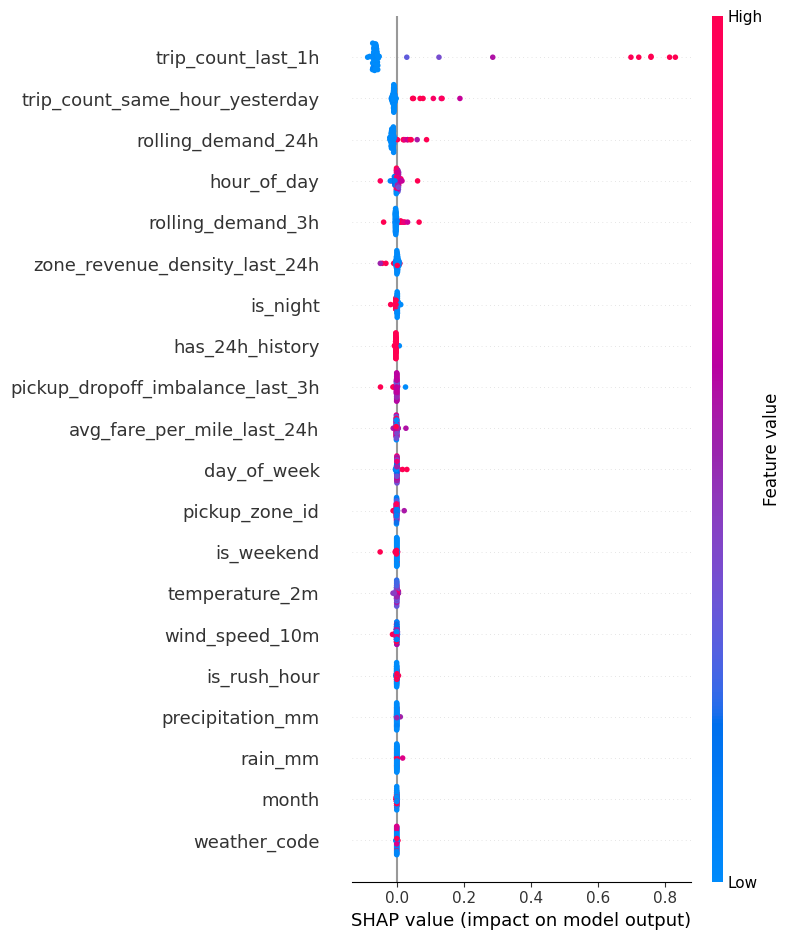

[OK] SHAP grafiği kaydedildi: /home/jovyan/figures/xai_shap_summary.png


In [9]:
# ============================================================
# 12. XAI - SHAP / LIME
# ============================================================

import matplotlib.pyplot as plt

import importlib.util

has_shap = importlib.util.find_spec("shap") is not None
has_lime = importlib.util.find_spec("lime") is not None

X_background = X_train.sample(min(80, len(X_train)), random_state=42)
X_sample = X_test.sample(min(80, len(X_test)), random_state=42)

if has_shap:
    import shap

    print("[OK] SHAP bulundu. Model-agnostic SHAP analizi yapılacak.")

    def predict_fn(data):
        data_df = pd.DataFrame(data, columns=feature_cols)
        return best_model.predict_proba(data_df)[:, 1]

    try:
        explainer = shap.Explainer(predict_fn, X_background)
        shap_values = explainer(X_sample)

        shap.summary_plot(shap_values, X_sample, show=False)
        fig_path = FIGURES_DIR / "xai_shap_summary.png"
        plt.tight_layout()
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()

        print("[OK] SHAP grafiği kaydedildi:", fig_path)

    except Exception as e:
        print("[UYARI] SHAP analizi başarısız oldu:")
        print(e)

        if hasattr(best_model, "feature_importances_"):
            importance_df = pd.DataFrame({
                "feature": feature_cols,
                "importance": best_model.feature_importances_
            }).sort_values("importance", ascending=False)

            importance_path = OUTPUTS_DIR / "fallback_feature_importance.csv"
            importance_df.to_csv(importance_path, index=False)

            display(importance_df.head(20))
            print("Fallback feature importance kaydedildi:", importance_path)

elif has_lime:
    import lime
    import lime.lime_tabular

    print("[OK] LIME bulundu. LIME analizi yapılacak.")

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_cols,
        class_names=["Low Demand", "High Demand"],
        mode="classification"
    )

    sample_index = 0

    exp = lime_explainer.explain_instance(
        X_test.iloc[sample_index].values,
        best_model.predict_proba,
        num_features=10
    )

    lime_path = OUTPUTS_DIR / "xai_lime_explanation.html"
    exp.save_to_file(str(lime_path))

    print("[OK] LIME açıklaması kaydedildi:", lime_path)

else:
    print("[UYARI] SHAP veya LIME kurulu değil.")
    print("Final teslim için SHAP veya LIME kurulu olmalı.")

## 13. Finansal Simülasyon ve Threshold Optimizasyonu

Model çıktıları finansal karar senaryosuna dönüştürülmüştür. Simülasyonda her threshold değeri için TP, FP, FN ve TN değerleri hesaplanmış, ardından net fayda ve ROI üretilmiştir.

Finansal varsayımlar:

- **True Positive:** Yüksek talep doğru tahmin edilir ve ek gelir elde edilir.
- **False Positive:** Gereksiz araç yönlendirilir ve operasyon maliyeti oluşur.
- **False Negative:** Yüksek talep kaçırılır ve fırsat kaybı oluşur.
- **True Negative:** Aksiyon alınmaz ve ek maliyet oluşmaz.

Çalışan sonuçlara göre en kârlı threshold değeri **0.75**, ROI değeri yaklaşık **3.12**, net fayda ise **307705** olarak bulunmuştur.

Threshold ROI tablosu:


,threshold,TP,FP,FN,TN,net_benefit,operation_cost,ROI
9,0.75,2743,73,210,26974,307705,98560,3.122007
7,0.65,2786,115,167,26932,315265,101535,3.104988
8,0.70,2763,101,190,26946,310925,100240,3.101806
5,0.55,2818,141,135,26906,321075,103565,3.100227
4,0.50,2830,157,123,26890,323035,104545,3.089913
6,0.60,2796,133,157,26914,316735,102515,3.089645
3,0.45,2836,168,117,26879,323910,105140,3.080749
2,0.40,2846,181,107,26866,325555,105945,3.072868
1,0.35,2862,200,91,26847,328250,107170,3.062891
0,0.30,2869,232,84,26815,328600,108535,3.027595



En kârlı threshold: 0.75
En yüksek ROI: 3.1220068993506493
Net fayda: 307705.0
Kaydedildi: /home/jovyan/model_outputs/roi_threshold_optimization.csv


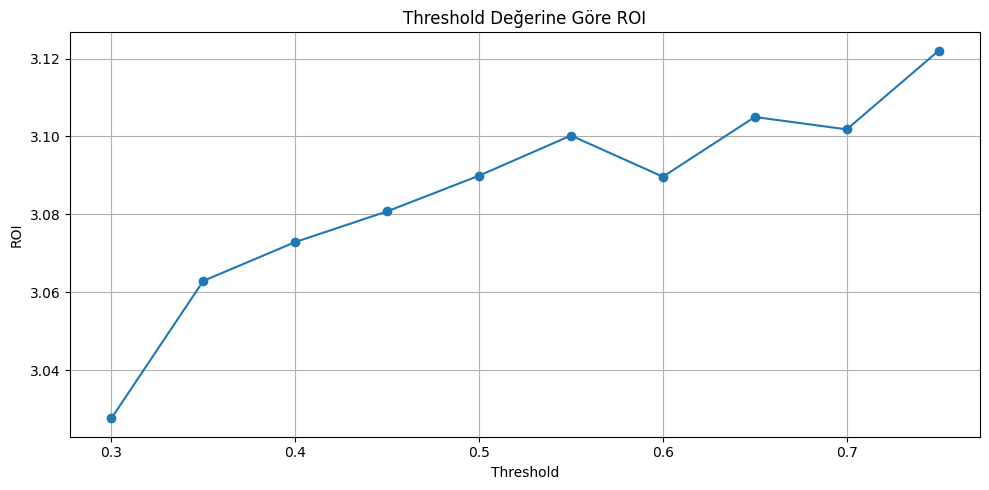

Kaydedildi: /home/jovyan/figures/roi_threshold_curve.png


In [10]:
# ============================================================
# 13. ROI + THRESHOLD OPTIMIZATION
# ============================================================

EXTRA_REVENUE_TP = 120
COST_FP = 35
OPPORTUNITY_COST_FN = 90

roi_base = pd.DataFrame({
    "actual_high_demand": y_test.values,
    "predicted_probability": y_prob_best
})

roi_rows = []

for threshold in np.arange(0.30, 0.76, 0.05):
    pred = (roi_base["predicted_probability"] >= threshold).astype(int)
    actual = roi_base["actual_high_demand"]

    tp = int(((pred == 1) & (actual == 1)).sum())
    fp = int(((pred == 1) & (actual == 0)).sum())
    fn = int(((pred == 0) & (actual == 1)).sum())
    tn = int(((pred == 0) & (actual == 0)).sum())

    net_benefit = (tp * EXTRA_REVENUE_TP) - (fp * COST_FP) - (fn * OPPORTUNITY_COST_FN)
    operation_cost = max((tp + fp) * COST_FP, 1)
    roi = net_benefit / operation_cost

    roi_rows.append({
        "threshold": round(float(threshold), 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "net_benefit": net_benefit,
        "operation_cost": operation_cost,
        "ROI": roi
    })

roi_df = pd.DataFrame(roi_rows).sort_values("ROI", ascending=False)

print("Threshold ROI tablosu:")
display(roi_df)

best_threshold_row = roi_df.iloc[0]
best_threshold = best_threshold_row["threshold"]

print("\nEn kârlı threshold:", best_threshold)
print("En yüksek ROI:", best_threshold_row["ROI"])
print("Net fayda:", best_threshold_row["net_benefit"])

roi_path = OUTPUTS_DIR / "roi_threshold_optimization.csv"
roi_df.to_csv(roi_path, index=False)

print("Kaydedildi:", roi_path)


roi_plot_df = roi_df.sort_values("threshold")

plt.figure(figsize=(10, 5))
plt.plot(roi_plot_df["threshold"], roi_plot_df["ROI"], marker="o")
plt.title("Threshold Değerine Göre ROI")
plt.xlabel("Threshold")
plt.ylabel("ROI")
plt.grid(True)
plt.tight_layout()

fig_path = FIGURES_DIR / "roi_threshold_curve.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Kaydedildi:", fig_path)

## 14. Kafka Demand Alert Simülasyonu

Bu bölüm, model tahmininin operasyonel alarm mekanizmasına nasıl dönüştürülebileceğini gösterir. En kârlı threshold değerini aşan örnek bir yüksek talep tahmini Kafka topic'ine alarm mesajı olarak gönderilmiştir.

In [14]:
# ============================================================
# KAFKA DEMAND ALERT SIMULATION - DÜZELTİLMİŞ VERSİYON
# ============================================================

import json
from datetime import datetime

try:
    from kafka import KafkaProducer
    from kafka.admin import KafkaAdminClient, NewTopic
    from kafka.errors import TopicAlreadyExistsError

    admin = KafkaAdminClient(
        bootstrap_servers=KAFKA_BOOTSTRAP,
        client_id=f"urbanflow-admin-{RUN_ID}"
    )

    try:
        admin.create_topics([
            NewTopic(
                name=KAFKA_TOPIC,
                num_partitions=3,
                replication_factor=1
            )
        ])
        print("[OK] Topic oluşturuldu:", KAFKA_TOPIC)

    except TopicAlreadyExistsError:
        print("[OK] Topic zaten var:", KAFKA_TOPIC)

    except Exception as e:
        if "TopicAlreadyExists" in str(e):
            print("[OK] Topic zaten var:", KAFKA_TOPIC)
        else:
            raise

    finally:
        admin.close()

    # En kârlı threshold üzerinde alarm üretilecek örnek seç
    sample_alert = X_test.copy()
    sample_alert["predicted_probability"] = y_prob_best
    sample_alert = sample_alert[sample_alert["predicted_probability"] >= best_threshold].head(1)

    if len(sample_alert) == 0:
        print("[UYARI] Threshold üzerinde alarm üretilecek örnek yok.")
    else:
        row = sample_alert.iloc[0]

        alert_message = {
            "project": "UrbanFlow AI",
            "run_id": RUN_ID,
            "pickup_zone_id": int(row["pickup_zone_id"]),
            "predicted_high_demand_probability": float(row["predicted_probability"]),
            "selected_threshold": float(best_threshold),
            "recommended_action": "dispatch_extra_taxi",
            "created_at": datetime.utcnow().isoformat()
        }

        producer = KafkaProducer(
            bootstrap_servers=KAFKA_BOOTSTRAP,
            value_serializer=lambda v: json.dumps(v).encode("utf-8")
        )

        producer.send(KAFKA_TOPIC, alert_message).get(timeout=10)
        producer.flush()
        producer.close()

        print("[OK] Kafka alarm mesajı gönderildi:")
        print(alert_message)

except Exception as e:
    print("[UYARI] Kafka alarm simülasyonu tamamlanamadı:")
    print(e)

[OK] Topic zaten var: student.adminboot.urbanflow.weather.alerts
[OK] Kafka alarm mesajı gönderildi:
{'project': 'UrbanFlow AI', 'run_id': 'bb5953e0', 'pickup_zone_id': 132, 'predicted_high_demand_probability': 0.9997930267381725, 'selected_threshold': 0.75, 'recommended_action': 'dispatch_extra_taxi', 'created_at': '2026-06-17T09:27:33.620354'}


## 15. Yönetimsel Özet Çıktısı

Bu bölüm, final PDF raporunda kullanılabilecek ana sonuçları `management_summary.json` dosyasına kaydeder. Çıktı; model adı, F1-score, ROC-AUC, en iyi threshold, ROI ve net fayda gibi yönetimsel karar metriklerini içerir.

In [16]:
# ============================================================
# 15. MANAGEMENT SUMMARY OUTPUT
# ============================================================

summary = {
    "project": "UrbanFlow AI",
    "run_id": RUN_ID,
    "hive_table": f"{DB_NAME}.{GOLD_TABLE}",
    "gold_record_count": int(len(eda_pdf)),
    "best_model": str(best_model_name),
    "best_model_f1": float(f1_score(y_test, y_pred_best, zero_division=0)),
    "best_model_roc_auc": float(roc_auc_score(y_test, y_prob_best)),
    "best_threshold": float(best_threshold),
    "best_threshold_roi": float(best_threshold_row["ROI"]),
    "best_threshold_net_benefit": float(best_threshold_row["net_benefit"]),
    "created_at": datetime.utcnow().isoformat()
}

summary_path = OUTPUTS_DIR / "management_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nKaydedildi:", summary_path)

{
  "project": "UrbanFlow AI",
  "run_id": "bb5953e0",
  "hive_table": "student_adminboot.urbanflow_gold_weather_v1",
  "gold_record_count": 381600,
  "best_model": "HistGradientBoosting",
  "best_model_f1": 0.9528619528619529,
  "best_model_roc_auc": 0.9991656294680926,
  "best_threshold": 0.75,
  "best_threshold_roi": 3.1220068993506493,
  "best_threshold_net_benefit": 307705.0,
  "created_at": "2026-06-17T09:28:28.405334"
}

Kaydedildi: /home/jovyan/model_outputs/management_summary.json


## 16. Kapanış

SparkSession kapatılır. Bu işlem, JupyterHub ve Spark kaynaklarının gereksiz yere açık kalmasını önler.

In [17]:
# ============================================================
# 16. STOP SPARK
# ============================================================

spark.stop()

print("[OK] SparkSession kapatıldı.")
print("UrbanFlow AI final weather notebook tamamlandı.")

[OK] SparkSession kapatıldı.
UrbanFlow AI final weather notebook tamamlandı.


# Final Sonuç Özeti

UrbanFlow AI projesi, üç farklı veri kaynağını birleştirerek bölge-saat düzeyinde taksi talebi tahmini yapmıştır. Spark/HDFS/Hive mimarisi ile Bronze, Silver ve Gold katmanları oluşturulmuş; Gold veri seti Hive External Table olarak kataloglanmıştır.

## Temel çıktılar

- Gold kayıt sayısı: **381600**
- En iyi model: **HistGradientBoosting**
- F1-score: **0.9528**
- ROC-AUC: **0.9991**
- En kârlı threshold: **0.75**
- ROI: **3.1220**
- Net fayda: **307705**
- SHAP grafiği: `figures/xai_shap_summary.png`
- ROI grafiği: `figures/roi_threshold_curve.png`
- Kafka alarm topic: `student.adminboot.urbanflow.weather.alerts`

Bu notebook, hem teknik veri bilimi sürecini hem de işletme odaklı finansal karar simülasyonunu birlikte göstermektedir.